In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math 
from scipy.integrate import simps
from scipy.stats import zscore
import scipy
from scipy.optimize import curve_fit

In [3]:
from IPython.display import display, Javascript

# This Javascript command finds the setting for new output areas and tells them not to scroll.
disable_scrolling_script = """
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}
"""
display(Javascript(disable_scrolling_script))

print("Scrolling for all new outputs in this notebook has been disabled.")

<IPython.core.display.Javascript object>

Scrolling for all new outputs in this notebook has been disabled.


In [4]:

# lick_data = pd.read_csv("reward_lick_zt4.csv")

# lick_data = pd.read_csv("licks_zt4_2.csv")
# lick_data = lick_data.iloc[8:,:]

#  lick_data = pd.read_csv("reward_licks_3.csv")

data_folder = "jupyter_data"


#this is cohort 2 R1------------------------------------------------------------------------------------------
#lick_data = pd.read_csv(os.path.join(data_folder, "licks_R2_ZT3.csv"))

#this is cohort 2 R2------------------------------------------------------------------------------------------
#lick_data = pd.read_csv(os.path.join(data_folder, "R2_exp2_licks_1.csv"))

#this is cohort 3 R1------------------------------------------------------------------------------------------
#lick_data = pd.read_csv(os.path.join(data_folder, "licks_c3_r1_ZT3_redo.csv"))

#this is cohort 3 R1------------------------------------------------------------------------------------------
#lick_data = pd.read_csv(os.path.join(data_folder, "C3_R2_DD_redo_redo_ZT5.5.csv"))

#lick_data = pd.read_csv("R2_exp2_licks_1.csv")
#controls and ko positions are flipped here. controls 

# da_data = pd.read_csv("C2_R3_ZT5.csv")
#lick_data = pd.read_csv("licks_C2_R3_ZT5.csv") 

#  # this is cohort 3 R1
# lick_data = pd.read_csv("licks_c3_r1_ZT3_redo.csv")


# lick_data = pd.read_csv("wtmice_ZT5_stresstest.csv")
# lick_data = pd.read_csv("licks_acc_cohort3_R1.csv") #created at zt 5

# da_data = pd.read_csv("c3_r1_ZT3_DD_restart.csv")
# lick_data = pd.read_csv("licks_c3_r1_ZT3_redo.csv")

#lick_data = pd.read_csv("C3_R2_acc_ZT_2.5.csv")

# lick_data = pd.read_csv("C3_acc_ZT7.5_wallsideONLY.csv")

lick_data = pd.read_csv(os.path.join(data_folder, "C3_R2_DD_redo_redo_ZT5.5.csv"))
# #timestamps = da_data['Timestamp']
#this is bmal1 rg vta KO acc cohort 1------------------------------------------------------------------------------------------
#lick_data = pd.read_csv(os.path.join(data_folder, "acc_ZT9_21926.csv"))

lickstamps = lick_data['time']

start_lick = lickstamps.iloc[0]


adjusted_lickstamps = lickstamps - start_lick
lick_data['time'] = adjusted_lickstamps
#10802
#unix is in seconds. even values are water, odd values are sucrose.        
#npm is in seconds

print(lick_data.head(20))




    cage  value    time
0    100    100   0.000
1      0      0   0.000
2      1      0   0.000
3      2      0   0.000
4      3      0   0.000
5      4      0   0.000
6      5      0   0.000
7      6      0   0.000
8      7      0   0.000
9      2      1   8.757
10     2      0   8.762
11     0      1  34.886
12     0      0  35.125
13     0      1  35.134
14     2      1  35.465
15     2      0  35.470
16     0      0  35.840
17     0      1  35.903
18     0      0  40.760
19     0      1  41.042


In [5]:
count = 0
for val in lick_data['value']:
    if val == 100:
        count += 1
print(f"Value 100 appears {count} times in the 'value' column.")

Value 100 appears 192 times in the 'value' column.


In [6]:
def split_lick(walls):
    min_value = 0
    max_value = 7
    tot_walls = np.arange(min_value, max_value + 1, 1)
    full_time = walls['time'].max()  # Assuming 'time' is the column for time stamps

    for val in tot_walls:
        if val % 2 == 0:
            variable_name = f"M{val}_water"
        else:
            variable_name = f"M{val}_sug"

        # Filter data for the current cage
        cage_data = walls[walls['cage'] == val]
        times = cage_data['time'].to_numpy()
        values = cage_data.iloc[:, 1].to_numpy()  # Assuming the second column contains lick values

        # Create data_with_time with all data
        data_with_time = np.column_stack([times, values])
        
        # Initialize lists for filtered data
        filtered_times = []
        filtered_values = []

        # Process data to find valid intervals
        in_lick = False
        start_time = None

        for i in range(len(values)):
            if values[i] == 1:
                if not in_lick:
                    start_time = times[i]
                    in_lick = True
            elif values[i] == 0 and in_lick:
                end_time = times[i]
                interval = end_time - start_time
                if 0.02 <= interval <= 0.1:
                    filtered_times.extend([start_time, end_time])
                    filtered_values.extend([1, 0])
                in_lick = False

        # Check if no filtered data was found and initialize an empty array
        if not filtered_times:
            # Initialize an empty array for this variable
            globals()[variable_name] = np.empty((0, 2))  # Empty array with shape (0, 2)
            continue

        # Recreate filtered data with time and values
        filtered_data = np.column_stack([filtered_times, filtered_values])
        filtered_data = filtered_data[filtered_data[:, 0].argsort()]  # Sort by time

        # Store the result in the global namespace
        globals()[variable_name] = filtered_data

        # Interval extraction
        start_time = 0
        interval_duration = 900  # 15 minutes in seconds
        skip_duration = 2700  # 45 minutes in seconds
        interval_count = 1

        while start_time < full_time:
            end_time = start_time + interval_duration
            interval_mask = (filtered_data[:, 0] >= start_time) & (filtered_data[:, 0] < end_time)
            interval_data = filtered_data[interval_mask]
            interval_var_name = f"{variable_name}_{interval_count}"
            globals()[interval_var_name] = interval_data

            start_time += interval_duration + skip_duration
            interval_count += 1

# Example usage
# Assuming `lick_data` is a DataFrame containing the lick data
split_lick(lick_data)



In [7]:
print(M2_water)

[[1.97019300e+03 1.00000000e+00]
 [1.97022400e+03 0.00000000e+00]
 [2.71455700e+03 1.00000000e+00]
 ...
 [6.84082675e+05 0.00000000e+00]
 [6.89568484e+05 1.00000000e+00]
 [6.89568516e+05 0.00000000e+00]]


In [8]:
import numpy as np
import pandas as pd # Used for the final print-out DataFrame

def analyze_latency_and_bouts_by_hour(sugar_variables, num_trials):
    """
    Analyzes lick data to calculate latency and bout counts for each hour-long trial,
    using the same iterative approach as the provided lick-counting code.

    Args:
        sugar_variables (list): A list of global variable names for sucrose data
                                (e.g., ['M1_sug', 'M3_sug', 'M5_sug', 'M7_sug']).
        num_trials (int): The total number of hourly trials to analyze.

    Returns:
        tuple: A tuple of two dictionaries:
               - latency_results: {mouse_name: [lat_hr1, lat_hr2, ...]}
               - bout_results: {mouse_name: [bouts_hr1, bouts_hr2, ...]}
    """
    # --- Dictionaries to store the final results ---
    latency_results = {}
    bout_results = {}

    # --- Define experimental parameters ---
    HOUR_S = 3600
    PRE_REWARD_PERIOD_S = 300
    BOUT_ILI_S = 10

    # --- Iterate through each mouse's sugar variable, just like the example ---
    for sugar_var in sugar_variables:
        # Access the complete dataset for the current mouse from global scope
        sugar_data = globals()[sugar_var]

        # Extract the time and value columns
        all_times = sugar_data[:, 0]
        all_values = sugar_data[:, 1]

        # --- Lists to store results for the CURRENT mouse across all hours ---
        latencies_per_hour = []
        bouts_per_hour = []
        
        current_time = 0  # Initialize the start of the first hour

        # --- THIS IS THE CORE ITERATION LOGIC, MIMICKING YOUR CODE ---
        # Iterate over each hour in the time range
        while current_time < num_trials * HOUR_S:
            period_start = current_time
            period_end = current_time + HOUR_S

            # --- Default values for the hour ---
            latency_for_this_hour = np.nan
            bouts_for_this_hour = 0

            # 1. Isolate all lick data within the current 1-hour window
            hourly_mask = (all_times >= period_start) & (all_times < period_end)
            hourly_times = all_times[hourly_mask]
            
            # If there's any data at all in this hour, proceed with analysis
            if hourly_times.size > 0:
                hourly_values = all_values[hourly_mask]

                # 2. Define the reward period and isolate data within it
                reward_start_time = period_start + PRE_REWARD_PERIOD_S
                reward_mask = hourly_times >= reward_start_time
                
                # Check if any licks occurred in the reward period
                if np.any(reward_mask):
                    reward_data = np.column_stack([hourly_times[reward_mask], hourly_values[reward_mask]])
                    
                    # Find the first lick event (value == 1) in the reward period
                    first_lick_events = reward_data[reward_data[:, 1] == 1]

                    if first_lick_events.size > 0:
                        # --- Latency Calculation ---
                        first_lick_abs_time = first_lick_events[0, 0]
                        latency_for_this_hour = first_lick_abs_time - reward_start_time

                        # --- Bout Calculation ---
                        bouts_for_this_hour = 1  # The first lick starts the first bout
                        for i in range(1, len(reward_data)):
                            # A new bout starts with a 'lick on' (1) after a 'lick off' (0)
                            if reward_data[i, 1] == 1 and reward_data[i-1, 1] == 0:
                                inter_lick_interval = reward_data[i, 0] - reward_data[i-1, 0]
                                if inter_lick_interval >= BOUT_ILI_S:
                                    bouts_for_this_hour += 1

            # Append the results for this hour (even if they are default values)
            latencies_per_hour.append(latency_for_this_hour)
            bouts_per_hour.append(bouts_for_this_hour)
            
            # Move to the next hour
            current_time += HOUR_S
        
        # Store the complete list of results for the current mouse
        latency_results[sugar_var] = latencies_per_hour
        bout_results[sugar_var] = bouts_per_hour

    return latency_results, bout_results

In [9]:
# ===================================================================
#   Main Script Execution (CORRECTED VERSION)
# ===================================================================

# Assume your 'split_lick()' and 'analyze_latency_and_bouts_by_hour' functions
# have already been defined.

# --- 1. Set up the necessary input variables for the analysis function ---

# Define the list of sucrose variable names you want to analyze
sugar_variables = ['M1_sug', 'M3_sug', 'M5_sug', 'M7_sug']

# --- THIS IS THE FIX ---
# Dynamically determine the total number of trials from your raw data
# instead of hard-coding it.
# This assumes your raw data is in a DataFrame called 'lick_data'.
try:
    trial_start_times = lick_data[lick_data['value'] == 100]['time'].unique()
    count = len(trial_start_times)
    print(f"Dynamically determined the number of trials: {count}")
except NameError:
    print("FATAL ERROR: The DataFrame 'lick_data' was not found. Cannot determine trial count.")
    # You would exit the script here
    # import sys
    # sys.exit()


# --- 2. Execute the analysis function with the CORRECT trial count ---
print(f"Running hourly analysis for all {count} trials...")
latencies, bouts = analyze_latency_and_bouts_by_hour(sugar_variables, count)
print("Hourly analysis complete.")


# --- 3. Print the results in a user-friendly format (Optional but good for checking) ---
print("\n" + "="*50)
print("      LATENCY AND BOUT ANALYSIS BY HOUR (Full Dataset)")
print("="*50)

# Create a combined DataFrame for a clean, table-like printout
all_results = []
for mouse_name in sugar_variables:
    for i in range(count):
        all_results.append({
            'Mouse': mouse_name,
            'Trial (Hour)': i + 1,
            'Latency (s)': latencies[mouse_name][i],
            'Bout Count': bouts[mouse_name][i]
        })

if all_results:
    results_df = pd.DataFrame(all_results)
    # Just print the head and tail to avoid a massive table in the console
    print("Full analysis DataFrame head:")
    print(results_df.head())
    print("...")
    print(results_df.tail())
    print(f"Shape of full analysis DataFrame: {results_df.shape}")
else:
    print("No results were generated. Please check your input variables.")

# ===================================================================
# NOW, you can run your NEXT block of code (the one that trims and saves).
# It will receive the full dataset and work correctly.
# ===================================================================

Dynamically determined the number of trials: 192
Running hourly analysis for all 192 trials...
Hourly analysis complete.

      LATENCY AND BOUT ANALYSIS BY HOUR (Full Dataset)
Full analysis DataFrame head:
    Mouse  Trial (Hour)  Latency (s)  Bout Count
0  M1_sug             1          NaN           0
1  M1_sug             2       10.399           3
2  M1_sug             3          NaN           0
3  M1_sug             4      423.758           1
4  M1_sug             5          NaN           0
...
      Mouse  Trial (Hour)  Latency (s)  Bout Count
763  M7_sug           188       71.576           1
764  M7_sug           189      511.803           1
765  M7_sug           190        4.297           5
766  M7_sug           191       11.392           1
767  M7_sug           192      192.369           2
Shape of full analysis DataFrame: (768, 4)


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
# ==============================================================================
# ==============================================================================
# 1. CRITICAL CSV SAVING CODE BLOCK FOR DOWNSAMPLED DFF
# ==============================================================================
# ==============================================================================
# ===================================================================
#   Step 1: Setup - Your Parameters
# ===================================================================
# This script assumes the following variables already exist from your
# previous analysis step:
#   - latencies (dictionary of latency data)
#   - bouts (dictionary of bout data)
#   - sugar_variables (list of variable names like ['M1_sug', ...])
#   - count (total number of trials/hours)

# --- Your User-Defined Parameters for Data Extraction ---
DAYS_TO_SKIP = 1
START_ZT_OF_EXPERIMENT = 5
TARGET_START_ZT = 12

# --- Your Mouse ID Mapping Dictionary ---
# This is where you connect your real animal IDs to the code's variable names.
MOUSE_MAPPING = {
    #'Mouse_477F': 'M5_sug',
    'Mouse_615L': 'M3_sug',
    'Mouse_615K': 'M1_sug',
    'Mouse_615H': 'M5_sug',
    'Mouse_592K': 'M7_sug'
}

# ===================================================================
#   Step 2: Convert Your Input Dictionaries to DataFrames
# ===================================================================

# This step makes your data structure compatible with the processing logic.
latency_df = pd.DataFrame(latencies)
bout_df = pd.DataFrame(bouts)

print("\n" + "="*50)
print("      PROCESSING AND SAVING FILES FOR ACTOGRAMS")
print("="*50)

print("--- Initial DataFrames (from your real data) ---")
print("Latency DataFrame head:")
print(latency_df.head())
print(f"\nOriginal DataFrame shapes: Latency {latency_df.shape}, Bouts {bout_df.shape}")
print("-" * 40)

# ===================================================================
#   Step 3: Create Output Directories
# ===================================================================

# Define the names of the new subfolders
latency_folder_name = "latency_actograms"
bout_folder_name = "bout_actograms"

# Create Path objects for the directories
latency_dir = Path(latency_folder_name)
bout_dir = Path(bout_folder_name)

# Create the directories; 'exist_ok=True' prevents errors if they already exist
latency_dir.mkdir(exist_ok=True)
bout_dir.mkdir(exist_ok=True)

print("--- Directory Setup ---")
print(f"Ensured output directory exists: '{latency_dir.resolve()}'")
print(f"Ensured output directory exists: '{bout_dir.resolve()}'")
print("-" * 40)

# ===================================================================
#   Step 4: Calculate Rows to Skip and Trim the DataFrames
# ===================================================================

print("--- Data Trimming ---")
# Each row represents 1 hour, so we calculate the total hourly offset.
rows_to_skip = (DAYS_TO_SKIP * 24) + (TARGET_START_ZT - START_ZT_OF_EXPERIMENT)

print(f"Calculation: ({DAYS_TO_SKIP} days * 24) + ({TARGET_START_ZT} - {START_ZT_OF_EXPERIMENT}) = {rows_to_skip} rows to skip.")

# Check if we have enough rows to perform the skip
if rows_to_skip >= len(latency_df):
    print(f"FATAL ERROR: Trying to skip {rows_to_skip} rows, but DataFrames only have {len(latency_df)} rows.")
    # You might want to exit the script here in a real scenario
    # import sys
    # sys.exit()
else:
    # Slice both DataFrames to get the data starting from the correct row
    trimmed_latency_df = latency_df.iloc[rows_to_skip:].copy()
    trimmed_bout_df = bout_df.iloc[rows_to_skip:].copy()
    
    # Reset index so the new DataFrames start from 0, which is cleaner.
    trimmed_latency_df.reset_index(drop=True, inplace=True)
    trimmed_bout_df.reset_index(drop=True, inplace=True)
    
    print(f"DataFrames trimmed. New shape should have {len(latency_df) - rows_to_skip} rows.")
    print(f"Actual new shapes: Latency {trimmed_latency_df.shape}, Bouts {trimmed_bout_df.shape}")
    print("-" * 40)

    # ===================================================================
    #   Step 5: Loop Through Mapping and Save Individual CSV Files
    # ===================================================================

    print("--- Saving Individual Files ---")

    # A list to process both data types efficiently
    data_to_process = [
        ('Latency', trimmed_latency_df, latency_dir),
        ('Bouts', trimmed_bout_df, bout_dir)
    ]

    for data_type, df, output_dir in data_to_process:
        print(f"\nProcessing {data_type} data...")
        # Iterate through your MOUSE_MAPPING dictionary
        for mouse_id, column_name in MOUSE_MAPPING.items():
            
            # Check if the column exists in the DataFrame
            if column_name in df.columns:
                # Select the single column for the current mouse
                mouse_data = df[[column_name]].copy()
                
                # Rename the column to the generic data type (e.g., 'Latency') for a clean CSV header
                mouse_data.rename(columns={column_name: data_type}, inplace=True)
                
                # Construct the full path for the output CSV file
                output_filepath = output_dir / f"{mouse_id}_{data_type.lower()}.csv"
                
                # Save the selected data to the CSV file without the pandas index
                #mouse_data.to_csv(output_filepath, index=False, float_format='%.3f', na_rep='NaN')
                
                print(f"  - Saved data for '{mouse_id}' to '{output_filepath}'")
            else:
                # Print a warning if a column from the mapping is not found
                print(f"  - WARNING: Column '{column_name}' for mouse '{mouse_id}' not found. Skipping.")

print("\nScript finished.")


      PROCESSING AND SAVING FILES FOR ACTOGRAMS
--- Initial DataFrames (from your real data) ---
Latency DataFrame head:
    M1_sug    M3_sug   M5_sug    M7_sug
0      NaN       NaN  107.123    12.850
1   10.399   324.033    4.264   194.787
2      NaN  2921.185   80.487    19.219
3  423.758     0.065      NaN  1086.871
4      NaN   459.471   10.448   142.761

Original DataFrame shapes: Latency (192, 4), Bouts (192, 4)
----------------------------------------
--- Directory Setup ---
Ensured output directory exists: '/Users/jojocook/Documents/wonderland/latency_actograms'
Ensured output directory exists: '/Users/jojocook/Documents/wonderland/bout_actograms'
----------------------------------------
--- Data Trimming ---
Calculation: (1 days * 24) + (12 - 5) = 31 rows to skip.
DataFrames trimmed. New shape should have 161 rows.
Actual new shapes: Latency (161, 4), Bouts (161, 4)
----------------------------------------
--- Saving Individual Files ---

Processing Latency data...
  - Saved 

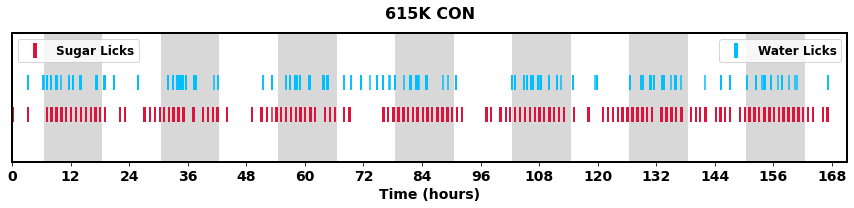

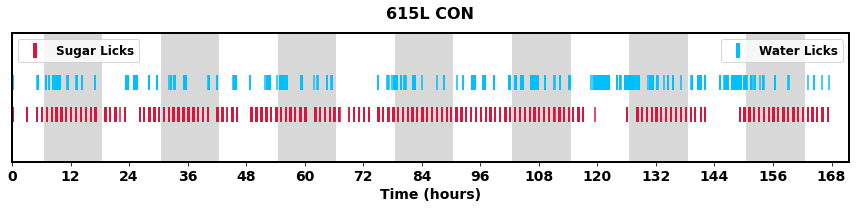

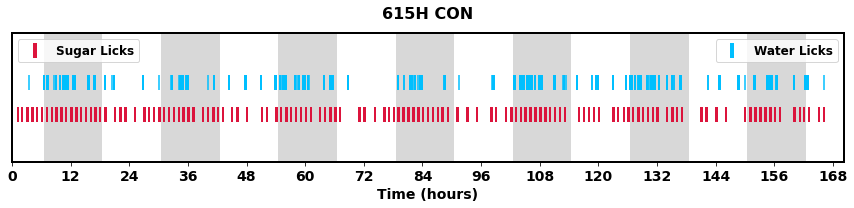

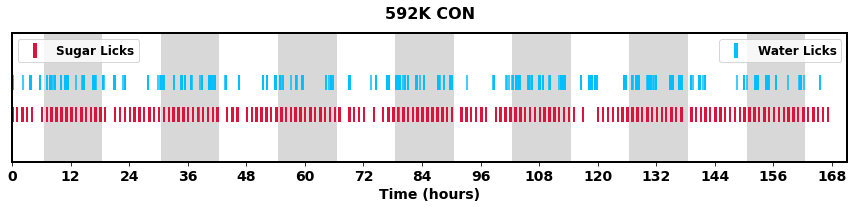

All individual mouse SVGs have been saved successfully with shifted 12h axes!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.lines import Line2D

# Define the variables for water and sugar
water_variables = ['M0_water', 'M2_water', 'M4_water', 'M6_water']
sugar_variables = ['M1_sug', 'M3_sug', 'M5_sug', 'M7_sug']
mouses = ['615K CON', '615L CON', '615H CON', '592K CON']

# Day and night lengths in hours
day_length = 12  # hours
night_length = 12  # hours
num_iterations = 0  # Number of day/night cycles (yellow)
num_it = 8  # Number of total iterations for night cycle (gray)
start_zt = 5.5
hour_offset = (12 - start_zt) - 1  

# Loop through each mouse INDIVIDUALLY
for water_var, sugar_var, id_m in zip(water_variables, sugar_variables, mouses):
    
    # Create a fresh 1x1 figure for just this mouse
    fig, ax = plt.subplots(figsize=(12, 3))
    
    # Access the water and sugar variables
    water_data = globals()[water_var]
    sugar_data = globals()[sugar_var]
    
    # Extract time and lick data
    water_time = water_data[:, 0] / 3600  
    water_vals = water_data[:, 1]
    
    sugar_time = sugar_data[:, 0] / 3600  
    sugar_vals = sugar_data[:, 1]
    
    sugar_mask = sugar_vals == 1
    water_mask = water_vals == 1
    
    # Plot Sugar Licks (y = 1.0)
    ax.plot(sugar_time[sugar_mask], sugar_vals[sugar_mask], '|', 
            markersize=15, markeredgewidth=1.5, color='crimson')

    # Plot Water Licks (y = 1.2)
    ax.plot(water_time[water_mask], water_vals[water_mask] + 0.2, '|', 
            markersize=15, markeredgewidth=1.5, color='deepskyblue')

    # Zoom in tightly on the Y-axis
    ax.set_ylim(0.7, 1.5) 
    ax.get_yaxis().set_visible(False)

    # Set bold title and labels
    ax.set_title(f'{id_m}', fontweight='bold', fontsize=16, pad=15)
    ax.set_xlabel('Time (hours)', fontweight='bold', fontsize=14)

    # --- Visually Skip Day 1 ---
    max_time = max(water_time.max() if len(water_time) else 0, 
                   sugar_time.max() if len(sugar_time) else 0)
    
    # Lock the left wall of the plot to hour 24
    ax.set_xlim(left=24, right=max_time + 4)

    # --- NEW: Fix and Re-Orient X-Axis Ticks ---
    # 1. Force a tick mark exactly every 12 hours
    ax.xaxis.set_major_locator(MultipleLocator(12))
    
    # 2. Subtract 24 from the printed label so the axis "starts" at 0
    ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{int(val - 24)}"))

    # Bold X-ticks
    ax.tick_params(axis='x', labelsize=14)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

    # Shading 
    for i in range(num_iterations):
        start_day = (i * 2 * day_length - hour_offset)
        end_day = start_day + day_length
        ax.axvspan(start_day, end_day, facecolor='yellow', alpha=0.3)
    
    for i in range(num_it):
        start_night = (i * 2 * day_length + day_length - hour_offset)
        end_night = start_night + night_length
        ax.axvspan(start_night, end_night, facecolor='gray', alpha=0.3)

    # --- Create Split Legends ---
    line_sugar = Line2D([0], [0], color='crimson', marker='|', linestyle='None', markersize=15, markeredgewidth=4.0)
    line_water = Line2D([0], [0], color='deepskyblue', marker='|', linestyle='None', markersize=15, markeredgewidth=4.0)
    
    leg1 = ax.legend([line_sugar], ['Sugar Licks'], loc='upper left', fontsize=12)
    plt.setp(leg1.get_texts(), fontweight='bold')
    ax.add_artist(leg1) 

    leg2 = ax.legend([line_water], ['Water Licks'], loc='upper right', fontsize=12)
    plt.setp(leg2.get_texts(), fontweight='bold')
    # --- HEAVY BOX ENCLOSURE ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2.0)
    # --- Save Individual SVG ---
    plt.tight_layout()
    
    safe_name = id_m.replace(" ", "_").replace("/", "-")
    save_path = f"licks_overtime_{safe_name}.svg"
    
    plt.savefig(save_path, format='svg', bbox_inches='tight', transparent=True)
    
    plt.show()
    plt.close(fig)

print("All individual mouse SVGs have been saved successfully with shifted 12h axes!")

/var/folders/bq/m9p30gcs71d414m2rvss357m0000gn/T/ipykernel_5132/1700009763.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticks(), fontweight='bold')


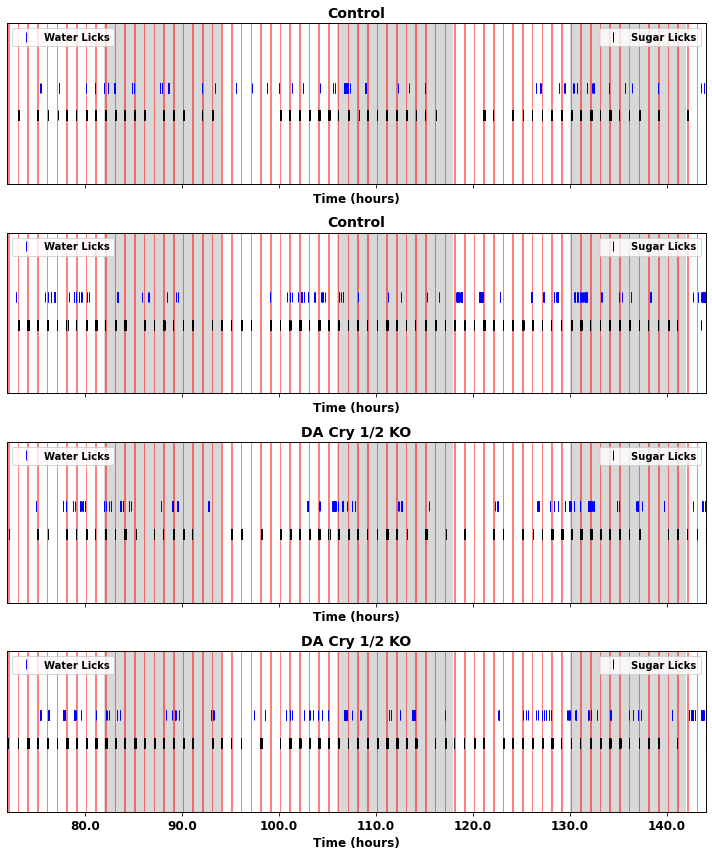

In [21]:
import numpy as np
import matplotlib.pyplot as plt

mouses = ['Control', 'Control', 'DA Cry 1/2 KO', 'DA Cry 1/2 KO']

# Day and night lengths in hours
day_length = 12  
night_length = 12  
num_iterations = 3  
num_it = 7
start_zt = 9
hour_offset = (12- start_zt) - 1
# Rectangle parameters
rectangle_len = 10 / 60  # Convert 10 minutes to hours
skip_duration = 50 / 60  # Convert 50 minutes to hours

# Create a 1x4 subplot
fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, water_var, sugar_var, id_m in zip(axs, water_variables, sugar_variables, mouses):
    water_data = globals()[water_var]
    sugar_data = globals()[sugar_var]
    
    water_time = water_data[:, 0] / 3600  
    water_vals = water_data[:, 1]
    
    sugar_time = sugar_data[:, 0] / 3600  
    sugar_vals = sugar_data[:, 1]

    # Plot Water Licks
    ax.plot(water_time[water_vals == 1], water_vals[water_vals == 1], '|', 
            markersize=10, markeredgewidth=1, color='blue', label='Water Licks')
    ax.set_ylim(0.97, 1.02)  

    # Secondary y-axis for Sugar Licks
    ax2 = ax.twinx()
    ax2.plot(sugar_time[sugar_vals == 1], sugar_vals[sugar_vals == 1], '|', 
             markersize=10, markeredgewidth=1, color='black', label='Sugar Licks')
    ax2.set_ylim(0.97, 1.04)  
    ax.set_xlim(24*3,24*6)
    ax.set_title(f'{id_m}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Time (hours)', fontweight='bold', fontsize=12)

    ax.get_yaxis().set_visible(False)  
    ax2.get_yaxis().set_visible(False)  

    ax.tick_params(axis='x', labelsize=12)  
    ax.set_xticklabels(ax.get_xticks(), fontweight='bold')

    # Day/Night Rectangles
    for i in range(num_iterations):
        start_day = (i * 2 * day_length - hour_offset)
        end_day = start_day + day_length
        ax.axvspan(start_day, end_day, facecolor='yellow', alpha=0.3)
    
    for i in range(num_it):
        start_night = (i * 2 * day_length + day_length - hour_offset)
        end_night = start_night + night_length
        ax.axvspan(start_night, end_night, facecolor='gray', alpha=0.3)

    # **Red Rectangles**
    max_sugar_time = np.ceil(np.max(sugar_time))  # Max time rounded up
    start_time = 0.083333  

    while start_time < 280:
        ax.axvspan(start_time, start_time + rectangle_len, facecolor='red', alpha=0.5)
        start_time += rectangle_len + skip_duration  # Move to next position

    # Legends
    legend1 = ax.legend(loc='upper left', fontsize=10)
    legend2 = ax2.legend(loc='upper right', fontsize=10)
    plt.setp(legend1.get_texts(), fontweight='bold')
    plt.setp(legend2.get_texts(), fontweight='bold')

plt.tight_layout()
#plt.savefig('wt_mice.png')
plt.show()
plt.close(fig)


In [22]:
# SAVE HOURLY LICK COUNT 
lick_counts = {}
hour_length = 3600
round = 'C1_R2_ZT4'
# Iterate through each water and sugar variable
for water_var, sugar_var in zip(water_variables, sugar_variables):
    # Access the water and sugar data
    water_data = globals()[water_var]
    sugar_data = globals()[sugar_var]

    # Extract time and lick data
    water_times = water_data[:, 0]
    water_vals = water_data[:, 1]
    sugar_times = sugar_data[:, 0]
    sugar_vals = sugar_data[:, 1]

    water_licks_per_hour = []
    sucrose_licks_per_hour = []
    
    current_time = 0  # Initialize the current time (in seconds)

    # Iterate over each hour in the time range
    while current_time < count *hour_length:
        period_start = current_time
        period_end = current_time + hour_length

        # Create masks to filter the data within the current 1-hour window
        water_mask = (water_times >= period_start) & (water_times < period_end)
        sugar_mask = (sugar_times >= period_start) & (sugar_times < period_end)

        # Count the licks in the current window
        num_water_licks = np.sum(water_vals[water_mask] == 1)
        num_sugar_licks = np.sum(sugar_vals[sugar_mask] == 1)

        # Append the results to the lists
        water_licks_per_hour.append(num_water_licks)
        sucrose_licks_per_hour.append(num_sugar_licks)
        
        # Move to the next hour
        current_time += hour_length
    
    # Store the results in the dictionary
    lick_counts[water_var] = water_licks_per_hour
    lick_counts[sugar_var] = sucrose_licks_per_hour

# Convert to DataFrame and save as CSV
lick_counts_df = pd.DataFrame(lick_counts)
#lick_counts_df.to_csv(f"hourly_lick_counts{round}.csv", index=False)


In [23]:
import pandas as pd

# Load the existing DataFrame
#lick_counts_df = pd.read_csv("hourly_lick_countsC2R3.csv")

# Define indices for day and night separation
start_index = 79-24  # Skip until dusk of first DD day
num_hours_per_phase = 12  # Each night or day lasts 12 hours
num_iterations = 3  # Three full day/night cycles

# Collect day and night data separately
day_data = []
night_data = []

for i in range(num_iterations):
    night_start = start_index + (i * 2 * num_hours_per_phase)
    night_end = night_start + num_hours_per_phase
    day_start = night_end
    day_end = day_start + num_hours_per_phase

    night_data.append(lick_counts_df.iloc[night_start:night_end])
    day_data.append(lick_counts_df.iloc[day_start:day_end])

# Concatenate to get 36 rows each
night_df = pd.concat(night_data, ignore_index=True)
day_df = pd.concat(day_data, ignore_index=True)

# Create the final DataFrame with deinterleaved day and night columns

final_df = pd.DataFrame()
for col in lick_counts_df.columns:
    final_df[f"{col}_day"] = day_df[col].values
    final_df[f"{col}_night"] = night_df[col].values
percent_nonzero = (final_df > 0).sum() / (num_iterations*12) * 100

# Append the percentage as a new row
final_df.loc["Percent_Nonzero"] = percent_nonzero

# Save to CSV
#final_df.to_csv(f"total_lickcount_daynight{round}.csv", index=False)

In [24]:
import pandas as pd
import numpy as np

# Create a list to store interval lick count data
interval_lick_counts = []

# Iterate through each interval (x)
for interval in range(1, count + 1):  
    interval_data = {"Interval": interval}  # Start row with interval number

    # Iterate through each cage, ensuring correct water/sugar assignment
    for cage in range(0, 7, 2):  # Even numbers for water
        water_var = f"M{cage}_water_{interval}"
        sugar_var = f"M{cage+1}_sug_{interval}"  # Odd numbers for sugar

        # Get lick counts or default to 0 if variable not found
        interval_data[f"M{cage}_water"] = np.sum(globals()[water_var][:, 1] == 1) if water_var in globals() else 0
        interval_data[f"M{cage+1}_sug"] = np.sum(globals()[sugar_var][:, 1] == 1) if sugar_var in globals() else 0

    # Append the row
    interval_lick_counts.append(interval_data)

# Convert to DataFrame and save as CSV
interval_lick_counts_df = pd.DataFrame(interval_lick_counts)
#interval_lick_counts_df.to_csv(f"interval_lick_counts_{round}.csv", index=False)

In [25]:
import pandas as pd

# Load the existing DataFrame
df = interval_lick_counts_df

# Define indices for day and night separation
start_index = start_index # Skip first 77 rows
num_hours_per_phase = 12  # Each night or day lasts 12 hours
num_iterations = 3  # Three full day/night cycles

# Collect day and night data separately
day_data = []
night_data = []

for i in range(num_iterations):
    night_start = start_index + (i * 2 * num_hours_per_phase)
    night_end = night_start + num_hours_per_phase
    day_start = night_end
    day_end = day_start + num_hours_per_phase

    night_data.append(df.iloc[night_start:night_end])
    day_data.append(df.iloc[day_start:day_end])

# Concatenate to get 36 rows each
night_df = pd.concat(night_data, ignore_index=True)
day_df = pd.concat(day_data, ignore_index=True)

# Create the final DataFrame with deinterleaved day and night columns
final_df = pd.DataFrame()

for col in df.columns[1:]:  # Skip the "Interval" column
    final_df[f"{col}_day"] = day_df[col].values
    final_df[f"{col}_night"] = night_df[col].values

# Save to CSV
#final_df.to_csv(f"interval_counts_daynight_{round}.csv", index=False)

In [26]:
# CIRCADIAN LICK COUNTS
lick_counts = {}
hour_length = 3600
start_hour = 79-24 #subtract 1 for index here   # Start from hour 81 (i.e., skip [0,81) hours)
num_hours = 24*6          # Count for next 5 days = 120 hours

# Iterate through each water and sugar variable
for water_var, sugar_var in zip(water_variables, sugar_variables):
    water_data = globals()[water_var]
    sugar_data = globals()[sugar_var]

    water_times = water_data[:, 0]
    water_vals = water_data[:, 1]
    sugar_times = sugar_data[:, 0]
    sugar_vals = sugar_data[:, 1]

    water_licks_per_hour = []
    sucrose_licks_per_hour = []

    for hour in range(start_hour, start_hour + num_hours):
        period_start = hour * hour_length
        period_end = period_start + hour_length

        water_mask = (water_times >= period_start) & (water_times < period_end)
        sugar_mask = (sugar_times >= period_start) & (sugar_times < period_end)

        num_water_licks = np.sum(water_vals[water_mask] == 1)
        num_sugar_licks = np.sum(sugar_vals[sugar_mask] == 1)

        water_licks_per_hour.append(num_water_licks)
        sucrose_licks_per_hour.append(num_sugar_licks)

    lick_counts[water_var] = water_licks_per_hour
    lick_counts[sugar_var] = sucrose_licks_per_hour

# Convert to DataFrame and save as CSV
lick_counts_df_c = pd.DataFrame(lick_counts)
#lick_counts_df_c.to_csv(f"circadian_lick_counts{round}.csv", index=False)
print(lick_counts_df_c)

     M0_water  M1_sug  M2_water  M3_sug  M4_water  M5_sug  M6_water  M7_sug
0           0     825         0     271         0     367         4     223
1          27    1005         4      60        60     291         0     216
2          28    1031         4     375         0     274         2     259
3          57    1116         0      36       133     321        88     188
4          17    1015        18      42        78     458         4     118
..        ...     ...       ...     ...       ...     ...       ...     ...
139         0       0         0       0         0       0         0       0
140         0       0         0       0         0       0         0       0
141         0       0         0       0         0       0         0       0
142         0       0         0       0         0       0         0       0
143         0       0         0       0         0       0         0       0

[144 rows x 8 columns]


In [27]:
# def save_to_awd(variable, lick_counts, start_date, start_time):
#     awd_data = ["mice", start_date, start_time, "240", "0", "0", "X"] + [str(val) for val in lick_counts]
#     awd_filename = f"{variable}.awd"
#     with open(awd_filename, 'w') as file:
#         for item in awd_data:
#             file.write(f"{item}\n")

# def process_and_save_awd_files_from_df(lick_counts_df_c, start_date, start_time):
#     # Specify the exact order of variable names
#     awd_names = [
#         "592B_con_water", "592B_con_sugar",
#         "48C_con_water", "48C_con_sugar",
#         "477F_con_water", "477F_con_sugar",
#         "592I_con_water", "592I_con_sugar"
#     ]

#     # Iterate in order, using both the custom name and the column from lick_counts_df
#     for col_name, awd_name in zip(lick_counts_df_c.columns, awd_names):
#         lick_counts = lick_counts_df_c[col_name].tolist()
#         save_to_awd(awd_name, lick_counts, start_date, start_time)

# # Call this after creating lick_counts_df
# start_date = "17-oct-2024"
# start_time = "18:00"
# process_and_save_awd_files_from_df(lick_counts_df_c, start_date, start_time)


In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
# ==============================================================================
# ==============================================================================
# 1. CRITICAL CSV SAVING CODE BLOCK FOR DOWNSAMPLED DFF
# ==============================================================================
# ==============================================================================


# --- 1. Setup: Your Parameters and Data ---

# NOTE: For demonstration purposes, I'm creating a sample DataFrame.
# In your actual code, you would already have 'lick_counts_df' loaded.
column_names = [f'M{i}_{"water" if i % 2 == 0 else "sug"}' for i in range(8)]

print("Original DataFrame head:")
print(lick_counts_df.head())
print("-" * 30)

# Your defined parameters
DAYS_TO_SKIP = 1
START_ZT_OF_EXPERIMENT = 5
TARGET_START_ZT = 12

# Your dictionary mapping the desired filename to the column name in the DataFrame
# I've added a few more examples based on your image.                                        2 
MOUSE_MAPPING = {
    '615L': 'M3_sug',
    '615K': 'M1_sug',
    '615H': 'M5_sug',
    '592K': 'M7_sug'
}

# --- 2. Create the Output Directory ---

# Define the name of the new subfolder
output_folder_name = "lick_counts_actograms"

# Create a Path object for the directory
output_dir = Path(output_folder_name)

# Create the directory. 'exist_ok=True' prevents an error if the folder already exists.
output_dir.mkdir(exist_ok=True)
print(f"Ensured output directory exists: '{output_dir.resolve()}'")
print("-" * 30)


# --- 3. Calculate Rows to Skip and Trim the DataFrame ---

# Each row represents 1 hour, so we skip 24 rows for each day.
rows_to_skip = (DAYS_TO_SKIP * 24) + (TARGET_START_ZT - START_ZT_OF_EXPERIMENT)

print(f"Calculation: ({DAYS_TO_SKIP} days * 24) + ({TARGET_START_ZT} - {START_ZT_OF_EXPERIMENT}) = {rows_to_skip} rows to skip.")

# Check if we have enough rows to skip
if rows_to_skip >= len(lick_counts_df):
    print(f"Error: Trying to skip {rows_to_skip} rows, but DataFrame only has {len(lick_counts_df)} rows.")
else:
    # Slice the DataFrame to get the data starting from the correct row
    # .iloc is used for integer-location based indexing
    trimmed_df = lick_counts_df.iloc[rows_to_skip:].copy()
    
    # Optional: Reset the index if you want the new DataFrame to start from index 0
    # trimmed_df.reset_index(drop=True, inplace=True)
    
    print(f"DataFrame trimmed. New shape: {trimmed_df.shape}")
    print("New DataFrame head (after skipping rows):")
    print(trimmed_df.head())
    print("-" * 30)

    # --- 4. Loop Through Mapping and Save CSV Files ---

    print("Starting to save files...")
    # Iterate through the key-value pairs in your MOUSE_MAPPING dictionary
    for mouse_id, column_name in MOUSE_MAPPING.items():
        
        # Check if the column actually exists in our DataFrame to avoid errors
        if column_name in trimmed_df.columns:
            # Select the single column of data for the current mouse
            # Using double brackets [[...]] ensures we get a DataFrame, not a Series
            mouse_data = trimmed_df[[column_name]]
            
            # Construct the full path for the output CSV file
            # The '/' operator is a clean way to join paths with pathlib
            output_filepath = output_dir / f"{mouse_id}_licks.csv"
            
            # Save the selected data to the CSV file
            # The index (which represents the hours) will be saved as the first column.
            # If you don't want the index, use: mouse_data.to_csv(output_filepath, index=False)
            #mouse_data.to_csv(output_filepath)
            
            print(f"  - Saved data for '{mouse_id}' ({column_name}) to '{output_filepath}'")
        else:
            # Print a warning if a column from the mapping is not found
            print(f"  - WARNING: Column '{column_name}' for mouse '{mouse_id}' not found in DataFrame. Skipping.")

print("\nScript finished.")

Original DataFrame head:
   M0_water  M1_sug  M2_water  M3_sug  M4_water  M5_sug  M6_water  M7_sug
0         1       0         4       0         7      51         0     195
1         1     418         0     611         0     155         0      72
2         0       0         0     258         0     158         0      35
3         0     389         0     225         0       0         1      55
4         0       0         0     306         0      11         0      36
------------------------------
Ensured output directory exists: '/Users/jojocook/Documents/wonderland/lick_counts_actograms'
------------------------------
Calculation: (1 days * 24) + (12 - 5) = 31 rows to skip.
DataFrame trimmed. New shape: (161, 8)
New DataFrame head (after skipping rows):
    M0_water  M1_sug  M2_water  M3_sug  M4_water  M5_sug  M6_water  M7_sug
31        53    1057         2      21         6     586         5      93
32        13     748         4      14        26     338        10     220
33        37

In [29]:
import pandas as pd
from pathlib import Path

# ==============================================================================
# 1. SETUP & PARAMETERS
# ==============================================================================

# Ensure lick_counts_df exists (Run Cell 17 first!)
if 'lick_counts_df' not in locals():
    raise NameError("Please run the 'SAVE HOURLY LICK COUNT' cell (Cell 17) first to generate lick_counts_df!")

# --- A. Time Alignment Parameters (UPDATED) ---
DAYS_TO_SKIP = 1           # User request: Skip 3 days
START_ZT_OF_EXPERIMENT = 5 # User request: Start at ZT 3
TARGET_START_ZT = 12         # User request: Orient to ZT 12

# --- B. Mouse Mapping (UPDATED for Water) ---
# Map your Mouse IDs to the "Mx_water" columns that exist in lick_counts_df
# Note: Based on your previous sugar map ('615L': 'M3_sug'), 
# the water partner is usually the even number below it (M2_water).
MOUSE_MAPPING = {
    # Water Licks
    #'477F': 'M4_water', 
    #'481C': 'M0_water',
    # '592B': 'M0_water', 
    # '592D': 'M2_water', 
    # '592I': 'M6_water',
    '615K': 'M0_water', 
    '615H': 'M4_water', 
    '592K': 'M6_water',
    # You can keep sugar here too if you want to overwrite/update them
    # '615L_sug': 'M3_sug', 
}

# --- C. Output Folder ---
output_folder_name = "water_counts_actograms" # Changed folder name for clarity
output_dir = Path(output_folder_name)
output_dir.mkdir(exist_ok=True)


# ==============================================================================
# 2. CALCULATION & SAVING
# ==============================================================================

# Calculate Rows (Hours) to Skip
# Logic: (Days * 24) + (Target - Start)
rows_to_skip = (DAYS_TO_SKIP * 24) + (TARGET_START_ZT - START_ZT_OF_EXPERIMENT)

print(f"Alignment Logic:")
print(f"  Skip {DAYS_TO_SKIP} days + ({TARGET_START_ZT} - {START_ZT_OF_EXPERIMENT}) hours shift")
print(f"  Total Rows to Skip: {rows_to_skip}")

if rows_to_skip >= len(lick_counts_df):
    print(f"Error: Skipping {rows_to_skip} rows exceeds data length ({len(lick_counts_df)}).")
else:
    # 1. Trim the DataFrame (Skip the early hours)
    trimmed_df = lick_counts_df.iloc[rows_to_skip:].copy()
    trimmed_df.reset_index(drop=True, inplace=True)
    
    print(f"Data trimmed. New shape: {trimmed_df.shape}")

    # 2. Save Individual Files
    for mouse_id, column_name in MOUSE_MAPPING.items():
        if column_name in trimmed_df.columns:
            # Extract column
            mouse_data = trimmed_df[[column_name]]
            
            # Rename column to generic 'Water_Licks' for the actogram script?
            # Or keep original name. Usually actogram script expects index 0.
            # mouse_data.columns = ['Water_Licks'] 
            
            output_filepath = output_dir / f"{mouse_id}_licks.csv"
            #mouse_data.to_csv(output_filepath)
            
            print(f"  -> Saved {mouse_id} ({column_name}) to {output_filepath}")
        else:
            print(f"  !! WARNING: Column {column_name} not found in lick_counts_df.")

print("\nProcessing Complete.")

Alignment Logic:
  Skip 1 days + (12 - 5) hours shift
  Total Rows to Skip: 31
Data trimmed. New shape: (161, 8)
  -> Saved 615K (M0_water) to water_counts_actograms/615K_licks.csv
  -> Saved 615H (M4_water) to water_counts_actograms/615H_licks.csv
  -> Saved 592K (M6_water) to water_counts_actograms/592K_licks.csv

Processing Complete.
